In [2]:
!pip install TextBlob


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [9]:
df = pd.read_csv('disaster_train.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [11]:
polarity_list = [];
for text in df['text']:
    p = TextBlob(text).sentiment.polarity
    polarity_list.append(p)

df['polarity'] = polarity_list
df['polarity'] .head(10)

0    0.00000
1    0.10000
2   -0.01875
3    0.00000
4    0.00000
5   -0.11250
6   -0.20000
7    0.50000
8    0.00000
9   -0.60000
Name: polarity, dtype: float64

In [19]:
sentiment = []
for p in df['polarity']:
    if p>0 :
        sentiment.append('Positive')
    elif p<0:
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')
df['sentiment'] = sentiment
# df['sentiment'].head(10)
print(df[['text','polarity','sentiment']].head(10))

                                                text  polarity sentiment
0  Our Deeds are the Reason of this #earthquake M...   0.00000   Neutral
1             Forest fire near La Ronge Sask. Canada   0.10000  Positive
2  All residents asked to 'shelter in place' are ...  -0.01875  Negative
3  13,000 people receive #wildfires evacuation or...   0.00000   Neutral
4  Just got sent this photo from Ruby #Alaska as ...   0.00000   Neutral
5  #RockyFire Update => California Hwy. 20 closed...  -0.11250  Negative
6  #flood #disaster Heavy rain causes flash flood...  -0.20000  Negative
7  I'm on top of the hill and I can see a fire in...   0.50000  Positive
8  There's an emergency evacuation happening now ...   0.00000   Neutral
9  I'm afraid that the tornado is coming to our a...  -0.60000  Negative


In [15]:
count = df['sentiment'].value_counts()
count

sentiment
Neutral     3573
Positive    2452
Negative    1588
Name: count, dtype: int64

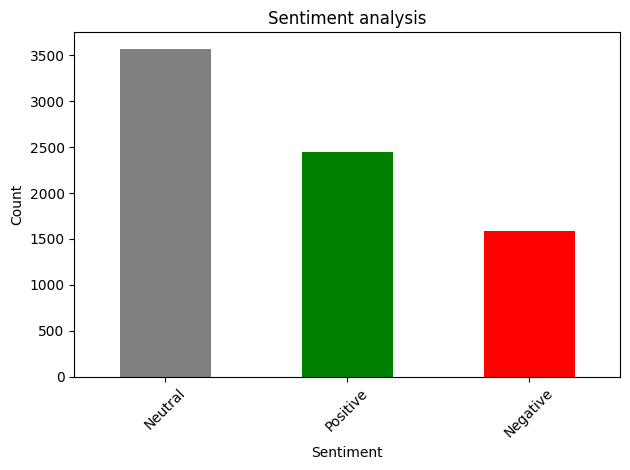

In [18]:
count.head(3).plot(kind='bar', color=['gray','green','red'])
plt.title('Sentiment analysis')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()